# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [12]:
data['sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [13]:
label_encoder = LabelEncoder()

data['sex_label'] = label_encoder.fit_transform(data['sex'])

data[['sex', 'sex_label']].head()

,sex,sex_label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

In [15]:
frecuencia_original = data['sex'].value_counts()
frecuencia_codificada = data['sex_label'].value_counts().sort_index()

print("Frecuencias originales:")
print(frecuencia_original)

print("\nFrecuencias codificadas:")
print(frecuencia_codificada)

Frecuencias originales:
sex
male      577
female    314
Name: count, dtype: int64

Frecuencias codificadas:
sex_label
0    314
1    577
Name: count, dtype: int64


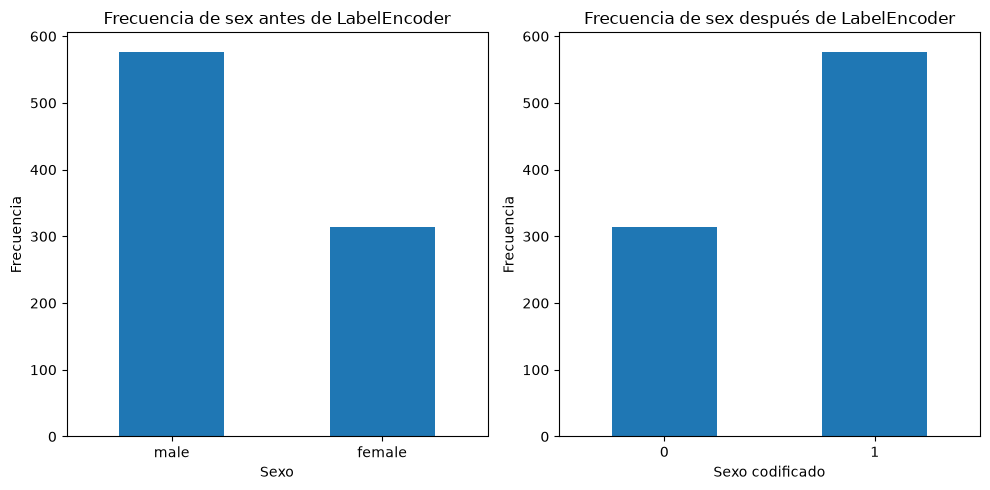

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
frecuencia_original.plot(kind='bar')
plt.title('Frecuencia de sex antes de LabelEncoder')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
frecuencia_codificada.plot(kind='bar')
plt.title('Frecuencia de sex después de LabelEncoder')
plt.xlabel('Sexo codificado')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [17]:
onehot_encoder = OneHotEncoder(sparse_output=False)

class_encoded = onehot_encoder.fit_transform(data[['class']])

class_encoded = pd.DataFrame(
    class_encoded,
    columns=onehot_encoder.get_feature_names_out(['class']),
    index=data.index
)

class_encoded.head()

,class_First,class_Second,class_Third
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
Elegiría OneHotEncoder para la mayoría de las variables categóricas, especialmente cuando las categorías no tienen un orden natural. Esta técnica crea una columna binaria para cada categoría y evita que el modelo interprete incorrectamente que existe una relación numérica entre ellas. Por ejemplo, si una variable tiene las categorías A, B y C, LabelEncoder las convertiría en 0, 1 y 2, lo que podría sugerir un orden que realmente no existe. OneHotEncoder las representa como variables independientes. Sin embargo, si las categorías tienen un orden natural, como bajo, medio y alto, puede ser más apropiado utilizar una codificación ordinal.